# LSST Time-Series Classification — Training on Colab

**Models**: InceptionTime · PatchTST · UniTS · Chronos-2 · MOMENT

Run cells top-to-bottom.  GPU runtime required (Runtime > Change runtime type > T4 GPU).

## 1. Environment Setup

We first clone our repo and setup the environment using `uv`.

In [1]:
!pwd

/content


In [3]:
!rm -rf dlts/
!git clone https://github.com/clijo/dlts.git

Cloning into 'dlts'...
remote: Enumerating objects: 230, done.
remote: Counting objects: 100% (230/230), done.
remote: Compressing objects: 100% (119/119), done.
remote: Total 230 (delta 125), reused 187 (delta 85), pack-reused 0 (from 0)
Receiving objects: 100% (230/230), 195.25 KiB | 6.97 MiB/s, done.
Resolving deltas: 100% (125/125), done.


In [4]:
%cd dlts/

/content/dlts


In [23]:
# !git pull

In [14]:
!uv sync

Resolved 109 packages in 1ms
Audited 104 packages in 65ms


In [6]:
# confirm GPU is available before training
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))

CUDA available: True
Device: Tesla T4


## 2. Weights & Biases Login (Optional)

In [ ]:
import os
import wandb

# Set the environment variable
os.environ["WANDB_API_KEY"] = "your_actual_api_key_here"

# Log in
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: clijo (clijo-jose) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 3. Train Models

Each command loads a fully self-contained config from `cfg/`.
Checkpoints and sidecar JSON files are written to `checkpoints/`.

### 3.1 InceptionTime (baseline)

In [8]:
!uv run python -m dlts.train --cfg cfg/inception_time.yaml --wandb.mode online

Split: 1967 train / 492 val / 2466 test  (val_fraction=0.2)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: clijo (clijo-jose) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ setting up run yf28efni (0.3s)
wandb: ⣷ setting up run yf28efni (0.3s)
wandb: ⣯ setting up run yf28efni (0.3s)
wandb: ⣟ setting up run yf28efni (0.3s)
wandb: ⡿ setting up run yf28efni (0.3s)
wandb: ⢿ setting up run yf28efni (0.8s)
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /content/dlts/wandb/run-20260316_193319-yf28efni
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run inception_time
wandb: ⭐️ View project at https://wandb.ai/clijo-jose/lsst-tsfm
wandb: 🚀 View run at https://wandb.ai/clijo-jose/lsst-tsfm/runs/yf28efni

>>> [SCRATCH] Training inceptio

### 3.2 PatchTST

In [9]:
!uv run python -m dlts.train --cfg cfg/patch_tst.yaml --wandb.mode online

Split: 1967 train / 492 val / 2466 test  (val_fraction=0.2)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: clijo (clijo-jose) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ setting up run c7bcx5k3 (0.3s)
wandb: ⣷ setting up run c7bcx5k3 (0.3s)
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /content/dlts/wandb/run-20260316_193528-c7bcx5k3
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run patch_tst
wandb: ⭐️ View project at https://wandb.ai/clijo-jose/lsst-tsfm
wandb: 🚀 View run at https://wandb.ai/clijo-jose/lsst-tsfm/runs/c7bcx5k3

>>> [SCRATCH] Training patch_tst end-to-end
[train] epoch=1/200 loss=3.3279 val_acc=0.0976 val_f1=0.0604 val_bal_acc=0.0901 val_logloss=2.5410 best_val_f1=0.0604
[train] epoch=2/200 loss=3.1950 va

### 3.3 UniTS

In [15]:
!uv run python -m dlts.train --cfg cfg/units.yaml --wandb.mode online

Split: 1967 train / 492 val / 2466 test  (val_fraction=0.2)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: clijo (clijo-jose) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ setting up run g8mya85u (0.3s)
wandb: ⣷ setting up run g8mya85u (0.3s)
wandb: ⣯ setting up run g8mya85u (0.3s)
wandb: ⣟ setting up run g8mya85u (0.3s)
wandb: ⡿ setting up run g8mya85u (0.3s)
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /content/dlts/wandb/run-20260316_201755-g8mya85u
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run units
wandb: ⭐️ View project at https://wandb.ai/clijo-jose/lsst-tsfm
wandb: 🚀 View run at https://wandb.ai/clijo-jose/lsst-tsfm/runs/g8mya85u

>>> [SCRATCH] Training units end-to-end
[train] epoch=1/200 loss=3.3911 val_acc=

### 3.4 Chronos-2 (foundation model — LP then FT)

In [11]:
!uv run python -m dlts.train --cfg cfg/chronos.yaml --wandb.mode online

Split: 1967 train / 492 val / 2466 test  (val_fraction=0.2)
config.json: 1.07kB [00:00, 4.01MB/s]
model.safetensors: 100% 478M/478M [00:03<00:00, 125MB/s] 
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: clijo (clijo-jose) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ setting up run jdacbu45 (0.3s)
wandb: ⣷ setting up run jdacbu45 (0.3s)
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /content/dlts/wandb/run-20260316_194032-jdacbu45
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run chronos2_adaptation
wandb: ⭐️ View project at https://wandb.ai/clijo-jose/lsst-tsfm
wandb: 🚀 View run at https://wandb.ai/clijo-jose/lsst-tsfm/runs/jdacbu45

>>> [FOUNDATION] Adapting chronos via 2-Stage LP-FT
>>> Stage 1: Freezing backbone for hea

### 3.5 MOMENT (foundation model — LP then FT)

In [12]:
!uv run python -m dlts.train --cfg cfg/moment.yaml --wandb.mode online

Split: 1967 train / 492 val / 2466 test  (val_fraction=0.2)
config.json: 2.88kB [00:00, 9.75MB/s]
configuration_moment.py: 3.20kB [00:00, 10.8MB/s]
A new version of the following files was downloaded from https://huggingface.co/HachiML/MOMENT-1-large-embedding-v0.1:
- configuration_moment.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
modeling_moment.py: 21.5kB [00:00, 20.6MB/s]
A new version of the following files was downloaded from https://huggingface.co/HachiML/MOMENT-1-large-embedding-v0.1:
- modeling_moment.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
model.safetensors: 100% 1.39G/1.39G [00:15<00:00, 92.2MB/s]
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: clijo (clijo-jose) to https://api.wandb.ai. 

## 4. Ensemble

Soft-voting ensemble weighted by each model's validation macro-F1.
Models below `--min_val_f1` are automatically excluded.
Result is written to `checkpoints/ensemble_result.json`.

In [22]:
# Custom: to lower the admission threshold or adjust temperature
!uv run python -m dlts.ensemble \
    --checkpoint_dir checkpoints/ \
    --min_val_f1 0.30 \
    --temperature 5.0

Device: cuda

Found 5 run(s), 4 eligible (val F1 ≥ 0.3).
  [EXCLUDED] moment                val_f1=0.2948

Loading LSST test set...

Loading  chronos               val_f1=0.3188 ...
  -> test_acc=0.2960  test_f1=0.3028  test_bal_acc=0.4238
Loading  inception_time        val_f1=0.4133 ...
  -> test_acc=0.3045  test_f1=0.3602  test_bal_acc=0.4593
Loading  patch_tst             val_f1=0.4307 ...
  -> test_acc=0.4100  test_f1=0.3870  test_bal_acc=0.4395
Loading  units                 val_f1=0.3127 ...
  -> test_acc=0.2364  test_f1=0.2845  test_bal_acc=0.3951

── Ensemble weights ─────────────────────────────────────
  chronos               val_f1=0.3188  weight=0.1878
  inception_time        val_f1=0.4133  weight=0.3013
  patch_tst             val_f1=0.4307  weight=0.3287
  units                 val_f1=0.3127  weight=0.1822

── Ensemble result ──────────────────────────────────────
  Accuracy          : 0.4177
  Macro F1          : 0.4473
  Balanced Accuracy : 0.5337
  Log-Loss          : 

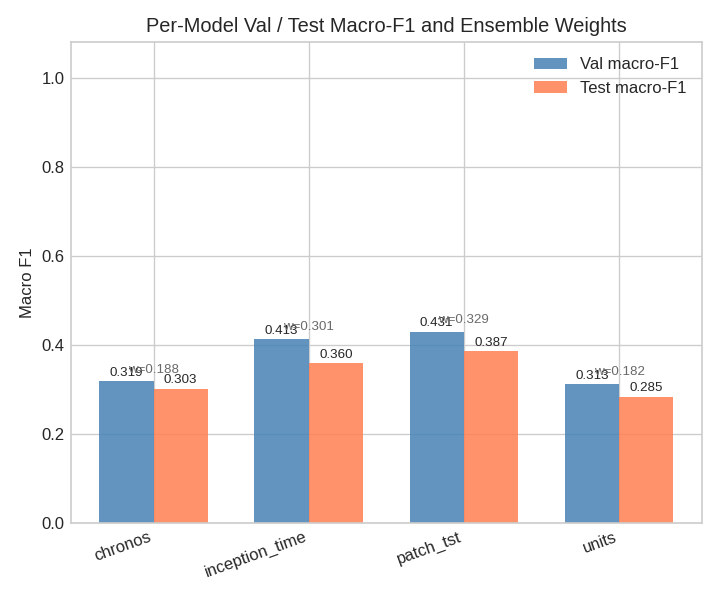

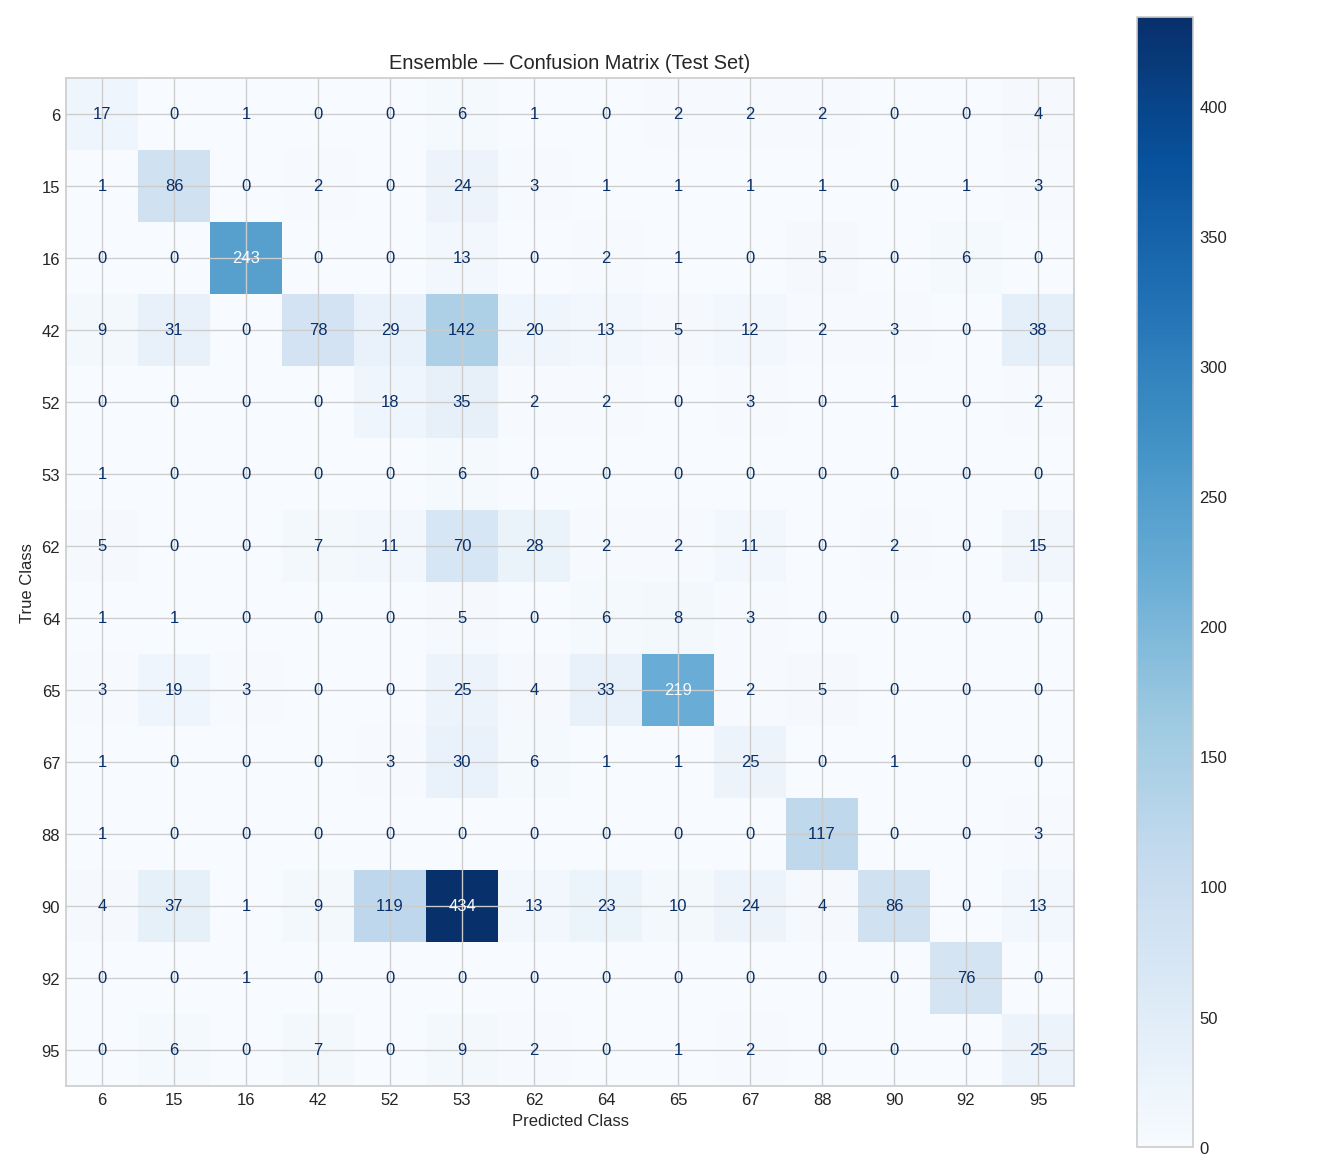

In [20]:
import IPython.display

IPython.display.display(
    IPython.display.Image("checkpoints/ensemble_model_comparison.png")
)
IPython.display.display(
    IPython.display.Image("checkpoints/ensemble_confusion_matrix.png")
)